## Softmax Regression — Multiclass Classification

### 1. Problem Setup

Assume we have a dataset

$$
\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \dots, (\mathbf{x}_N, y_N)\}
$$

where

$$
\mathbf{x}_i \in \mathbb{R}^D
$$

$$
y_i \in \{1, 2, \dots, K\}
$$

The goal is to classify each input into one of $K$ classes.

---

### 2. Model Representation

Softmax regression learns a weight matrix:

$$
\mathbf{W} \in \mathbb{R}^{D \times K}
$$

Each column corresponds to a class.

If, bias is included:

$$
\tilde{\mathbf{x}} = [1, \mathbf{x}]
$$

---

### 3. Linear Scores (Logits)

$$
\mathbf{z}_i = \mathbf{W}^T \mathbf{x}_i
$$

Matrix form:

$$
\mathbf{Z} = \mathbf{X}\mathbf{W}
$$

where

$$
\mathbf{Z} \in \mathbb{R}^{N \times K}
$$

---

### 4. Softmax Function

$$
P_{ik} = \frac{\exp(z_{ik})}{\sum_{j=1}^{K} \exp(z_{ij})}
$$

Numerical stability:

$$
z_{ik} \leftarrow z_{ik} - \max_j z_{ij}
$$

---

### 5. Prediction Rule

$$
\hat{y}_i = \arg\max_k P_{ik}
$$

---

### 6. One-Hot Encoding

$$
\mathbf{Y} \in \mathbb{R}^{N \times K}
$$

$$
Y_{ik} =
\begin{cases}
1 & \text{if sample } i \text{ belongs to class } k \\
0 & \text{otherwise}
\end{cases}
$$

---

### 7. Objective Function (Cross-Entropy Loss)

$$
L = -\sum_{i=1}^{N} \sum_{k=1}^{K} Y_{ik} \log(P_{ik})
$$

$$
L = - \sum_{i=1}^{N} \sum_{k=1}^{K} Y_{ik} \log P(y=k \mid \mathbf{x}_i)
$$

Matrix form:

$$
L = -\text{trace}(\mathbf{Y}^T \log \mathbf{P})
$$




---

### 8. Gradient of Loss

$$
\nabla_{\mathbf{W}} L = \mathbf{X}^T (\mathbf{P} - \mathbf{Y})
$$

With averaging:

$$
\nabla_{\mathbf{W}} L = \frac{1}{N} \mathbf{X}^T (\mathbf{P} - \mathbf{Y})
$$

---

### 9. Weight Update Rule

$$
\mathbf{W} \leftarrow \mathbf{W} - \eta \, \nabla_{\mathbf{W}} L
$$

where $\eta$ is the learning rate.

---

### 10. Initialization

$$
\mathbf{W} = 0
$$

At initialization:

$$
P_{ik} = \frac{1}{K}
$$

---

### 11. Iterative Optimization

Compute logits:

$$
\mathbf{Z} = \mathbf{X}\mathbf{W}
$$

Apply softmax:

$$
\mathbf{P} = \text{softmax}(\mathbf{Z})
$$

Compute loss:

$$
L = -\sum Y \log P
$$

Compute gradient:

$$
\nabla_{\mathbf{W}} = \frac{1}{N} \mathbf{X}^T (\mathbf{P} - \mathbf{Y})
$$

Update weights:

$$
\mathbf{W} \leftarrow \mathbf{W} - \eta \nabla_{\mathbf{W}}
$$

---

### 12. Convergence Criterion

$$
|L_t - L_{t-1}| < \text{tol}
$$

---

### 13. Numerical Stability

$$
\mathbf{Z} \leftarrow \mathbf{Z} - \max(\mathbf{Z}, \text{axis}=1)
$$

$$
\mathbf{P} = \text{clip}(\mathbf{P}, \epsilon, 1 - \epsilon)
$$

---

### 14. Geometric Interpretation

$$
\mathbf{W}_k^T \mathbf{x} = \mathbf{W}_j^T \mathbf{x}
$$

Each pair of classes defines a decision boundary.

The space is divided into $K$ regions.

---

### 15. Prediction

$$
\mathbf{Z}_{\text{test}} = \mathbf{X}_{\text{test}} \mathbf{W}
$$

$$
\mathbf{P}_{\text{test}} = \text{softmax}(\mathbf{Z}_{\text{test}})
$$

$$
\hat{y}_{\text{test}} = \arg\max_k P_{\text{test},k}
$$

$$
\hat{y}_{\text{test}} = \arg\max_k P(y=k \mid \mathbf{test})
$$

---

### 16. Algorithm Summary

- Convert labels to one-hot encoding  
- Initialize weights  

Repeat:

- Compute logits  
- Apply softmax  
- Compute loss  
- Compute gradient  
- Update weights  

Stop when loss converges  

---

### 17. Final Optimization Perspective

$$
\min_{\mathbf{W}} \; -\sum_{i=1}^{N} \sum_{k=1}^{K}
Y_{ik} \log \left(
\frac{\exp(\mathbf{W}_k^T \mathbf{x}_i)}
{\sum_{j} \exp(\mathbf{W}_j^T \mathbf{x}_i)}
\right)
$$

This produces a **probabilistic linear classifier** for multiclass problems.

In [1]:
class SoftmaxRegression:
    """
    Softmax Regression (Multiclass Logistic Regression) Classifier.

    Implements a linear classifier for multiclass classification using
    the softmax function and cross-entropy loss, optimized via gradient descent.

    Parameters
    ----------
    learning_rate : float, default=0.01
        Step size for gradient descent updates.

    max_iter : int, default=100000
        Maximum number of iterations for gradient descent.

    tol : float, default=1e-5
        Tolerance for early stopping based on loss improvement.

    fit_intercept : bool, default=True
        Whether to add a bias term to the features.
    """

    def __init__(self, learning_rate=0.01, max_iter=100000, tol=1e-5, fit_intercept=True):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.fit_intercept = fit_intercept

        self.weights=None
        self.K = None
        

    def _add_intercept(self,X):
        """
        Add a column of ones to X for the bias term.

        Parameters
        ----------
        X : ndarray of shape (N, D)
            Input feature matrix.

        Returns
        -------
        X_new : ndarray of shape (N, D+1)
            Feature matrix with bias column added.
        """
        
        if self.fit_intercept:
            N, D = X.shape
            X = np.hstack((np.ones((N,1)),X))
        return X

    def _softmax(self,Z):
        """
        Compute the softmax probabilities for each class.

        Parameters
        ----------
        Z : ndarray of shape (N, K)
            Linear logits computed as X @ W.

        Returns
        -------
        P : ndarray of shape (N, K)
            Softmax probabilities for each class.
        """
        # Subtract max for numerical stability
        Z_bar = Z- np.max(Z,axis=1,keepdims=True)
        expZ = np.exp(Z_bar)
        expZ /= np.sum(expZ,axis=1,keepdims=True)
        return expZ
        

    def _one_hot(self, y):
        """
        Convert class labels to one-hot encoded matrix.

        Parameters
        ----------
        y : ndarray of shape (N,)
            Class labels (integers 0..K-1).

        Returns
        -------
        Y : ndarray of shape (N, K)
            One-hot encoded labels.
        """
        self.classes_, y_encoded = np.unique(y, return_inverse=True)
        self.K = len(self.classes_)
        Y = np.eye(self.K)[y_encoded]
        return Y
        

    def fit(self,X,y):
        """
        Train the Softmax Regression model using gradient descent.

        Parameters
        ----------
        X : ndarray of shape (N, D)
            Training feature matrix.

        y : ndarray of shape (N,)
            Target class labels.

        Notes
        -----
        Updates weights iteratively. Stops early if loss improvement
        is smaller than tol.
        """
        
        all_loss = []
        # Add intercept if required

        if self.fit_intercept== True:
            X = self._add_intercept(X)
        N,D = X.shape
        
        # One-hot encode target labels

        Y = self._one_hot(y)
        # Initialize weights to zeros
        
        self.weights = np.zeros((D,self.K))
        print("Training in Process")
        
        for i in range(self.max_iter):
            # Compute logits
            Z = X @ self.weights
            
            # Compute softmax probabilities
            P = self._softmax(Z)
            P = np.clip(P,1e-12,1-1e-12) # Avoid log(0)
            
            # Compute cross-entropy loss
            loss = -np.trace(Y.T @ np.log(P))
            grad_loss = X.T @ (P-Y) / N

            # Update weights using gradient descent
            self.weights -= self.learning_rate * grad_loss
            all_loss.append(loss)
            
            # Early stopping if improvement is small
            if i>0 and abs(loss-all_loss[-2]) < self.tol:
                print(f"Solution converged at iteration : {i}")
                break
   

    def predict_proba(self,X):
        """
        Compute predicted probabilities for each class.

        Parameters
        ----------
        X : ndarray of shape (N, D)
            Input features.

        Returns
        -------
        P : ndarray of shape (N, K)
            Predicted probabilities for each class.
        """
        if self.fit_intercept:
            X = self._add_intercept(X)
        Z = X @ self.weights
        
        return self._softmax(Z)

    def predict(self,X):
        """
        Predict class labels for input samples.

        Parameters
        ----------
        X : ndarray of shape (N, D)
            Input features.

        Returns
        -------
        y_pred : ndarray of shape (N,)
            Predicted class labels.
        """
        P = self.predict_proba(X)
        
        return self.classes_[np.argmax(P,axis=1)]




## 1. Dataset



- **Classes:** \(0, 1, 2\)  
- **Features:** 2D points \((x_1, x_2)\)  
- All classes are **linearly separable**, allowing us to visualize **decision boundaries**.  

$$
\mathbf{X} = \{ \mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N \}, \quad
y_i \in \{0, 1, 2\}
$$






In [2]:
import numpy as np

np.random.seed(42)

N = 100

# Class 0 (top-right)
X0 = np.random.randn(N, 2) * 0.3 + np.array([3, 3])
y0 = np.zeros(N)

# Class 1 (bottom-left)
X1 = np.random.randn(N, 2) * 0.3 + np.array([-3, -3])
y1 = np.ones(N)

# Class 2 (top-left)
X2 = np.random.randn(N, 2) * 0.3 + np.array([-3, 3])
y2 = np.full(N, 2)

# Combine
X = np.vstack([X0, X1, X2])
y = np.hstack([y0, y1, y2])



---

## 2. Softmax Regression Model

Softmax Regression is used for **multiclass classification**.

- **Input:** 2D features  
- **Output:** Probability for each class  

The probability for class \(k\) is:

$$
P(y=k \mid \mathbf{x}) = \frac{\exp(\mathbf{w}_k^T \mathbf{x})}{\sum_{j=0}^{2} \exp(\mathbf{w}_j^T \mathbf{x})}
$$

**Cross-Entropy Loss:**

$$
\mathcal{L} = - \sum_{i=1}^{N} \sum_{k=0}^{2} y_{i,k} \log P(y=k \mid \mathbf{x}_i)
$$

where \(y_{i,k}\) is **one-hot encoded**:

$$
y_{i,k} =
\begin{cases}
1 & \text{if sample } i \text{ belongs to class } k \\
0 & \text{otherwise}
\end{cases}
$$

---


## 3. Model Training

In [3]:
model = SoftmaxRegression(
    learning_rate=0.1,
    max_iter=10000,
    tol=1e-5,
    fit_intercept=True
)

model.fit(X, y)

preds = model.predict(X)
accuracy = np.mean(preds == y)

print(f"Training Accuracy: {accuracy:.4f}")

Training in Process
Solution converged at iteration : 7026
Training Accuracy: 1.0000


---

## 4. Decision Boundary Visualization

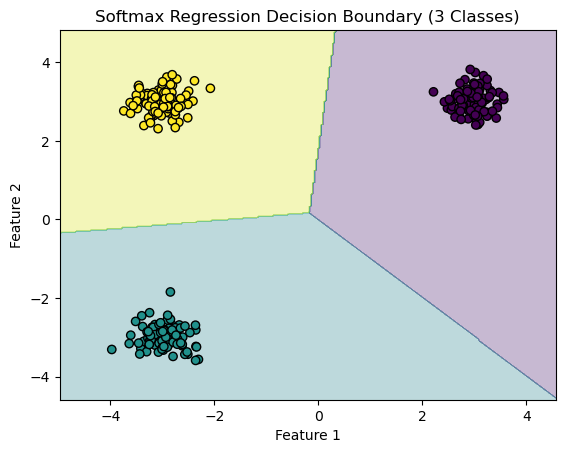

In [4]:
import matplotlib.pyplot as plt

# Create grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Flatten grid
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict on grid
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot original data
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.title("Softmax Regression Decision Boundary (3 Classes)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

---

## 5. Conclusion

- The dataset is **perfectly linearly separable**.  

- Softmax Regression **learns linear decision boundaries** separating the three classes.  

- Each region corresponds to the class with the **highest predicted probability**:

$$
\hat{y} = \arg\max_k P(y=k \mid \mathbf{x})
$$

- Misclassification is **zero** because the data is separable.  

- Decision boundaries are **straight lines** in 2D, as expected for linear Softmax Regression.

---